<a href="https://colab.research.google.com/github/Sakhiur2022/Signal/blob/main/notebooks/03_income_classification/03_eda_final_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPR-01 — Exploratory Data Analysis (Final Dataset)

**Ticket:** SPR-01
**Owner:** Sakhiur
**Depends on:** none
**Folder:** `notebooks/03_income_classification/`
**Output:** distribution report + figures in `results/figures/`, findings summary in `docs/findings/`

**A note on scikit-plot:** scikit-plot only covers model-evaluation plots (confusion matrix, ROC, precision-recall, learning curves), not raw-data exploration. There is no dataset yet to model at this stage, so it has nothing to plot here. It's used correctly downstream in SPR-04. This notebook instead applies uniform IEEE-grade static styling (high DPI, consistent fonts, colorblind-safe palette) across every plot by hand, which achieves the same publication-quality goal.

**Column names below follow the project's known schema** (`age`, `education_years`, `digital_index`, `income_class`, etc.). This specific file (`final_dataset_preprocessed_distributed_social_class.csv`) may have renamed or restructured columns, the filename suggests income/social class handling may differ. **Run the column-check cell in Section 2 first and adjust names before continuing.**

## 1. Download dataset from Hugging Face

In [1]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv

--2026-08-25 07:51:43--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv
Resolving huggingface.co (huggingface.co)... 3.167.112.25, 3.167.112.38, 3.167.112.45, ...
Connecting to huggingface.co (huggingface.co)|3.167.112.25|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6a7c7183f2c81824bdfb6fa9/e667362f3c877b4bc4e46b95a9b7382d66b4e3037af217c9b916437c0c549fcc?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27final_dataset_preprocessed_distributed_social_class.csv%3B+filename%3D%22final_dataset_preprocessed_distributed_social_class.csv%22%3B&response-content-type=text%2Fcsv&X-Xet-Cas-Uid=public&Expires=1787647903&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmE3YzcxODNmMmM4MTgyNGJkZmI2ZmE5L2U2NjczNjJmM2M4NzdiNGJjNGU0NmI5NWE5YjczODJkNjZiNGUzMDM3YWYyMTdjOWI5MTY0MzdjMGM1NDlmY2NcX

## 2. Load and inspect structure
Run this first and actually read the output before anything else in this notebook. Column names, dtypes, and the target column name are confirmed here, not assumed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

np.random.seed(42)
random.seed(42)

df = pd.read_csv('final_dataset_preprocessed_distributed_social_class.csv')

print('Shape:', df.shape)
print()
print('Columns:')
print(list(df.columns))
print()
print('Dtypes:')
print(df.dtypes)

Shape: (751622, 26)

Columns:
['age', 'education_years', 'weekly_workhours', 'digital_index', 'social_participation_index', 'gender_male', 'disabled', 'social_participant', 'agri_worker', 'disability_severity_ord', 'disability_vision', 'disability_mental', 'disability_walking', 'disability_hearing', 'disability_communication', 'disability_hand_finger', 'no_disability', 'digital_status', 'workhours_missing', 'income_class', 'region_Bali_Nusa', 'region_Eastern', 'region_Java', 'region_Kalimantan', 'region_Sulawesi', 'region_Sumatra']

Dtypes:
age                           float64
education_years               float64
weekly_workhours              float64
digital_index                 float64
social_participation_index    float64
gender_male                     int64
disabled                        int64
social_participant              int64
agri_worker                     int64
disability_severity_ord         int64
disability_vision               int64
disability_mental               int

In [3]:
df.head()

,age,education_years,weekly_workhours,digital_index,social_participation_index,gender_male,disabled,social_participant,agri_worker,disability_severity_ord,...,no_disability,digital_status,workhours_missing,income_class,region_Bali_Nusa,region_Eastern,region_Java,region_Kalimantan,region_Sulawesi,region_Sumatra
0,78.0,6.0,0.0,0.0,0.333333,1,0,1,0,0,...,1,0,1,No_income,0,0,0,0,0,1
1,65.0,6.0,0.0,0.0,0.333333,0,0,1,0,0,...,1,0,1,No_income,0,0,0,0,0,1
2,82.0,6.0,0.0,0.0,0.000000,1,0,0,0,0,...,1,0,1,No_income,0,0,0,0,0,1
3,65.0,6.0,0.0,0.0,0.000000,0,0,0,0,0,...,1,0,1,No_income,0,0,0,0,0,1
4,31.0,12.0,35.0,1.0,0.333333,1,0,1,0,0,...,1,2,0,Lower,0,0,0,0,0,1


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,751622.0,NaN,NaN,NaN,40.740282,16.457401,15.0,27.0,40.0,53.0,98.0
education_years,751622.0,NaN,NaN,NaN,8.809984,4.387781,1.0,6.0,9.0,12.0,22.0
weekly_workhours,751622.0,NaN,NaN,NaN,25.663808,22.863708,0.0,0.0,27.0,42.0,98.0
digital_index,751622.0,NaN,NaN,NaN,0.488496,0.801443,0.0,0.0,0.0,1.0,3.0
social_participation_index,751622.0,NaN,NaN,NaN,0.307531,0.171551,0.0,0.333333,0.333333,0.333333,1.0
gender_male,751622.0,NaN,NaN,NaN,0.495564,0.499981,0.0,0.0,0.0,1.0,1.0
disabled,751622.0,NaN,NaN,NaN,0.078034,0.268225,0.0,0.0,0.0,0.0,1.0
social_participant,751622.0,NaN,NaN,NaN,0.830292,0.375376,0.0,1.0,1.0,1.0,1.0
agri_worker,751622.0,NaN,NaN,NaN,0.021269,0.144279,0.0,0.0,0.0,0.0,1.0
disability_severity_ord,751622.0,NaN,NaN,NaN,0.101926,0.387313,0.0,0.0,0.0,0.0,3.0


## 3. Publication-quality plot styling (IEEE Access grade)
Applied globally so every figure in this notebook is consistent: high DPI for print, readable font sizes, colorblind-safe palette. Set once here, used everywhere below.

In [7]:
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5)
})

# Colorblind-safe qualitative palette (Okabe-Ito), works in grayscale print too
IEEE_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442']
sns.set_palette(IEEE_PALETTE)

os.makedirs('results/figures', exist_ok=True)
os.makedirs('docs/findings', exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f'results/figures/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4. Missing values check

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_table if len(missing_table) > 0 else 'No missing values found.')

No missing values found.


## 5. Target variable distribution: income_class
This is the single most important chart in this notebook. Confirms the real class imbalance (No_income / Lower / Middle / Upper) that SPR-02 has to handle.

income_class
No_income    327963
Lower        239425
Middle       175908
Upper          8326
Name: count, dtype: int64

income_class
No_income    43.63
Lower        31.85
Middle       23.40
Upper         1.11
Name: proportion, dtype: float64


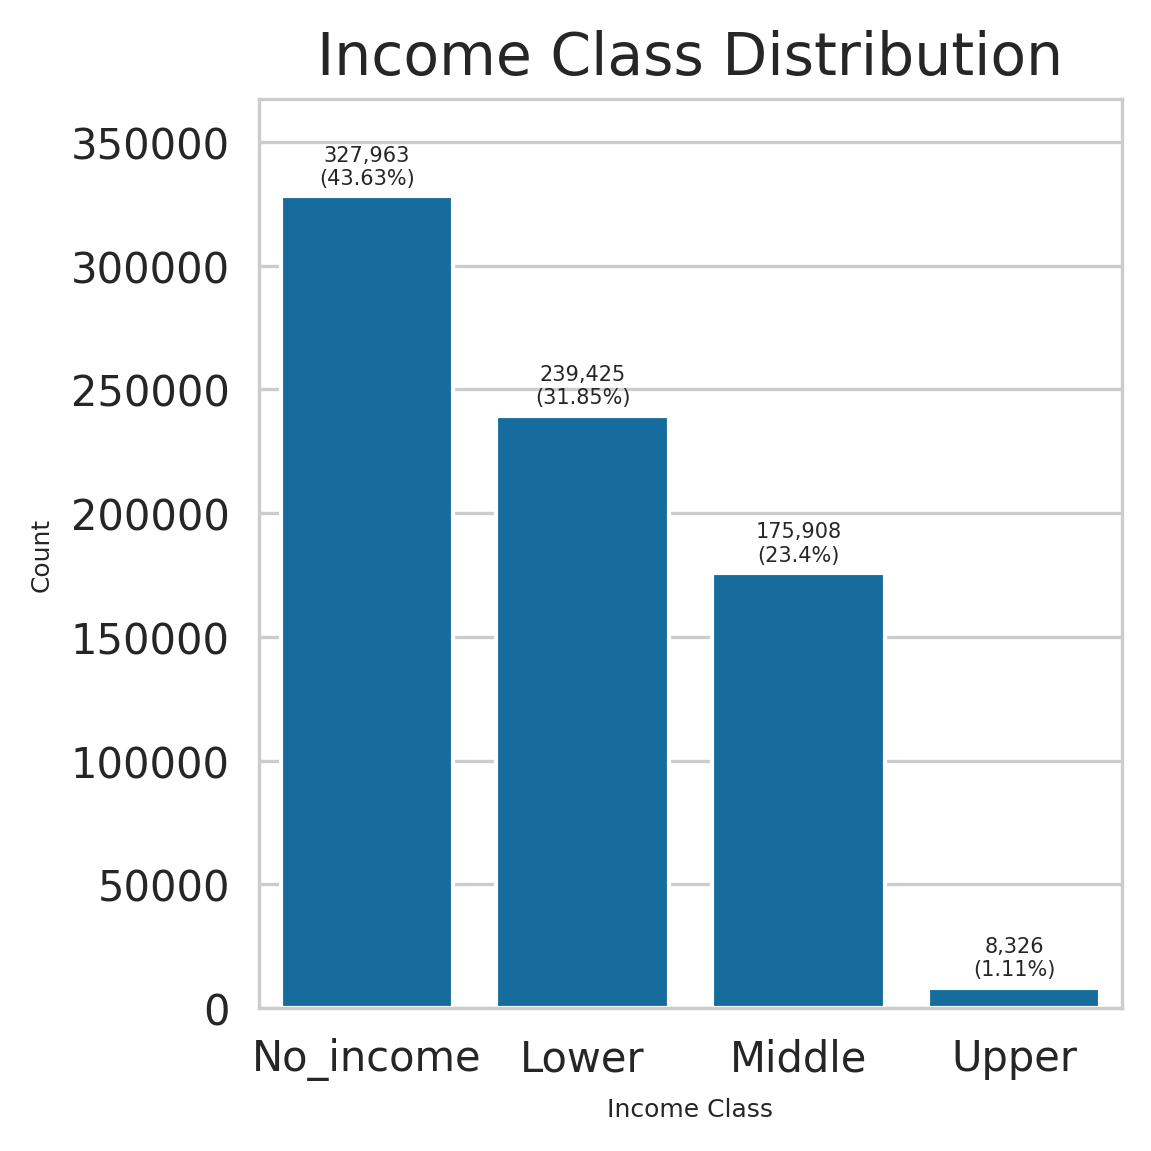

In [21]:
TARGET_COL = 'income_class'  # TODO: confirm this matches the actual column name from Section 2

class_counts = df[TARGET_COL].value_counts()
class_pct = df[TARGET_COL].value_counts(normalize=True).mul(100).round(2)

print(class_counts)
print()
print(class_pct)

plt.figure(figsize=(4, 4))
ax = sns.countplot(
    data=df,
    x=TARGET_COL,
    order=class_counts.index,
    color=IEEE_PALETTE[0]
)

# Add a little space above the bars so labels fit
plt.ylim(0, class_counts.max() * 1.12)

for i, count in enumerate(class_counts.values):
    pct = class_pct.iloc[i]
    ax.text(
        i,
        count + class_counts.max() * 0.01,
        f'{count:,}\n({pct}%)',
        ha='center',
        va='bottom',
        fontsize=5
    )

plt.title('Income Class Distribution')
plt.xlabel('Income Class', fontsize=6)
plt.ylabel('Count', fontsize=6)

plt.tight_layout(pad=0.5)
save_fig('target_distribution_income_class')

## 6. Upper-tail distribution check
Requested explicitly for this ticket. The Upper income class is known to be small (around 1% in the project's earlier profiling); this section looks specifically at what that tail looks like across continuous features, since it's the class every model will struggle with most.

In [10]:
upper_mask = df[TARGET_COL] == 'Upper'  # TODO: confirm exact label spelling from Section 2/5 output
upper_df = df[upper_mask]
non_upper_df = df[~upper_mask]

print(f'Upper class rows: {len(upper_df):,} ({len(upper_df)/len(df)*100:.2f}% of dataset)')
print()
print('Upper class summary statistics (numeric columns):')
upper_df.describe().T

Upper class rows: 8,326 (1.11% of dataset)

Upper class summary statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
age,8326.0,45.436464,10.861785,15.0,38.000000,45.000000,53.000000,98.0
education_years,8326.0,12.996757,4.103217,1.0,12.000000,12.000000,16.000000,22.0
weekly_workhours,8326.0,45.899712,17.567754,1.0,37.000000,42.000000,56.000000,98.0
digital_index,8326.0,1.796661,0.975911,0.0,1.000000,2.000000,3.000000,3.0
social_participation_index,8326.0,0.447474,0.227057,0.0,0.333333,0.333333,0.666667,1.0
gender_male,8326.0,0.800384,0.399735,0.0,1.000000,1.000000,1.000000,1.0
disabled,8326.0,0.038914,0.193402,0.0,0.000000,0.000000,0.000000,1.0
social_participant,8326.0,0.910521,0.285451,0.0,1.000000,1.000000,1.000000,1.0
agri_worker,8326.0,0.000240,0.015498,0.0,0.000000,0.000000,0.000000,1.0
disability_severity_ord,8326.0,0.044079,0.233223,0.0,0.000000,0.000000,0.000000,3.0


/tmp/ipykernel_2625/76819189.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='is_upper', y=col, ax=ax, palette=IEEE_PALETTE)
/tmp/ipykernel_2625/76819189.py:13: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.boxplot(data=plot_df, x='is_upper', y=col, ax=ax, palette=IEEE_PALETTE)
/tmp/ipykernel_2625/76819189.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='is_upper', y=col, ax=ax, palette=IEEE_PALETTE)
/tmp/ipykernel_2625/76819189.py:13: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.boxplot(data=plot_df, x='is_upper', y=col, ax=ax, palette=IEEE

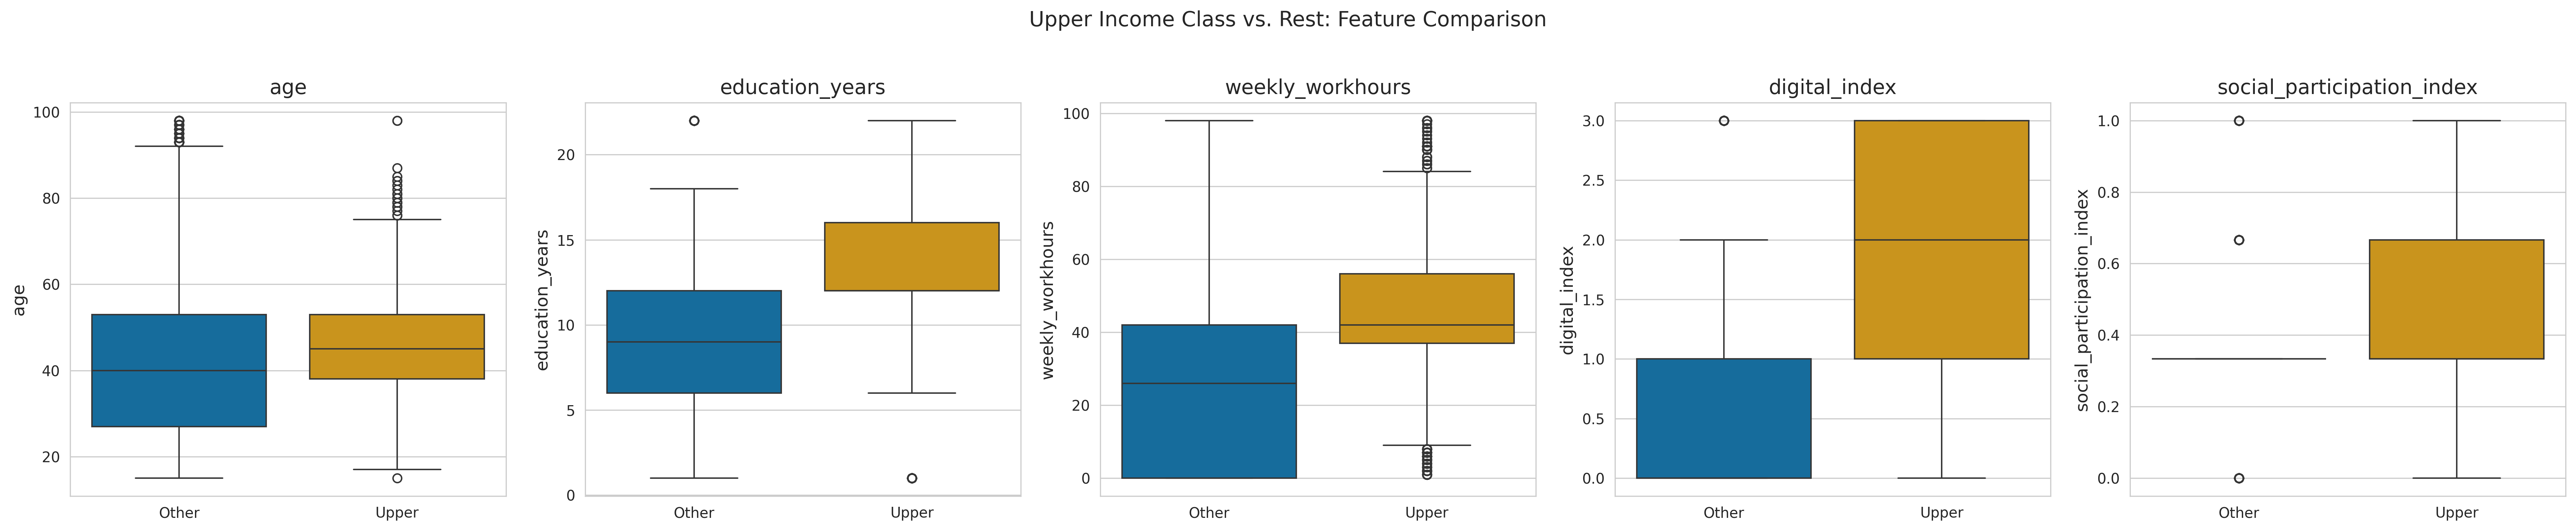

In [11]:
# Compare key continuous features between Upper and everyone else
continuous_candidates = ['age', 'education_years', 'weekly_workhours', 'digital_index',
                          'social_participation_index']
continuous_features = [c for c in continuous_candidates if c in df.columns]

fig, axes = plt.subplots(1, len(continuous_features), figsize=(5 * len(continuous_features), 5))
if len(continuous_features) == 1:
    axes = [axes]

for ax, col in zip(axes, continuous_features):
    plot_df = df.copy()
    plot_df['is_upper'] = np.where(upper_mask, 'Upper', 'Other')
    sns.boxplot(data=plot_df, x='is_upper', y=col, ax=ax, palette=IEEE_PALETTE)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Upper Income Class vs. Rest: Feature Comparison', y=1.02)
save_fig('upper_tail_feature_comparison')

## 7. Continuous feature distributions
One histogram per numeric feature, with a KDE overlay. Consistent styling from Section 3.

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Drop obvious one-hot / binary flag columns from this view, they're better shown as bar counts
binary_like = [c for c in numeric_cols if df[c].dropna().isin([0, 1]).all()]
continuous_only = [c for c in numeric_cols if c not in binary_like]

print('Continuous columns:', continuous_only)
print('Binary/flag columns (shown separately below):', binary_like)

Continuous columns: ['age', 'education_years', 'weekly_workhours', 'digital_index', 'social_participation_index', 'disability_severity_ord', 'digital_status']
Binary/flag columns (shown separately below): ['gender_male', 'disabled', 'social_participant', 'agri_worker', 'disability_vision', 'disability_mental', 'disability_walking', 'disability_hearing', 'disability_communication', 'disability_hand_finger', 'no_disability', 'workhours_missing', 'region_Bali_Nusa', 'region_Eastern', 'region_Java', 'region_Kalimantan', 'region_Sulawesi', 'region_Sumatra']


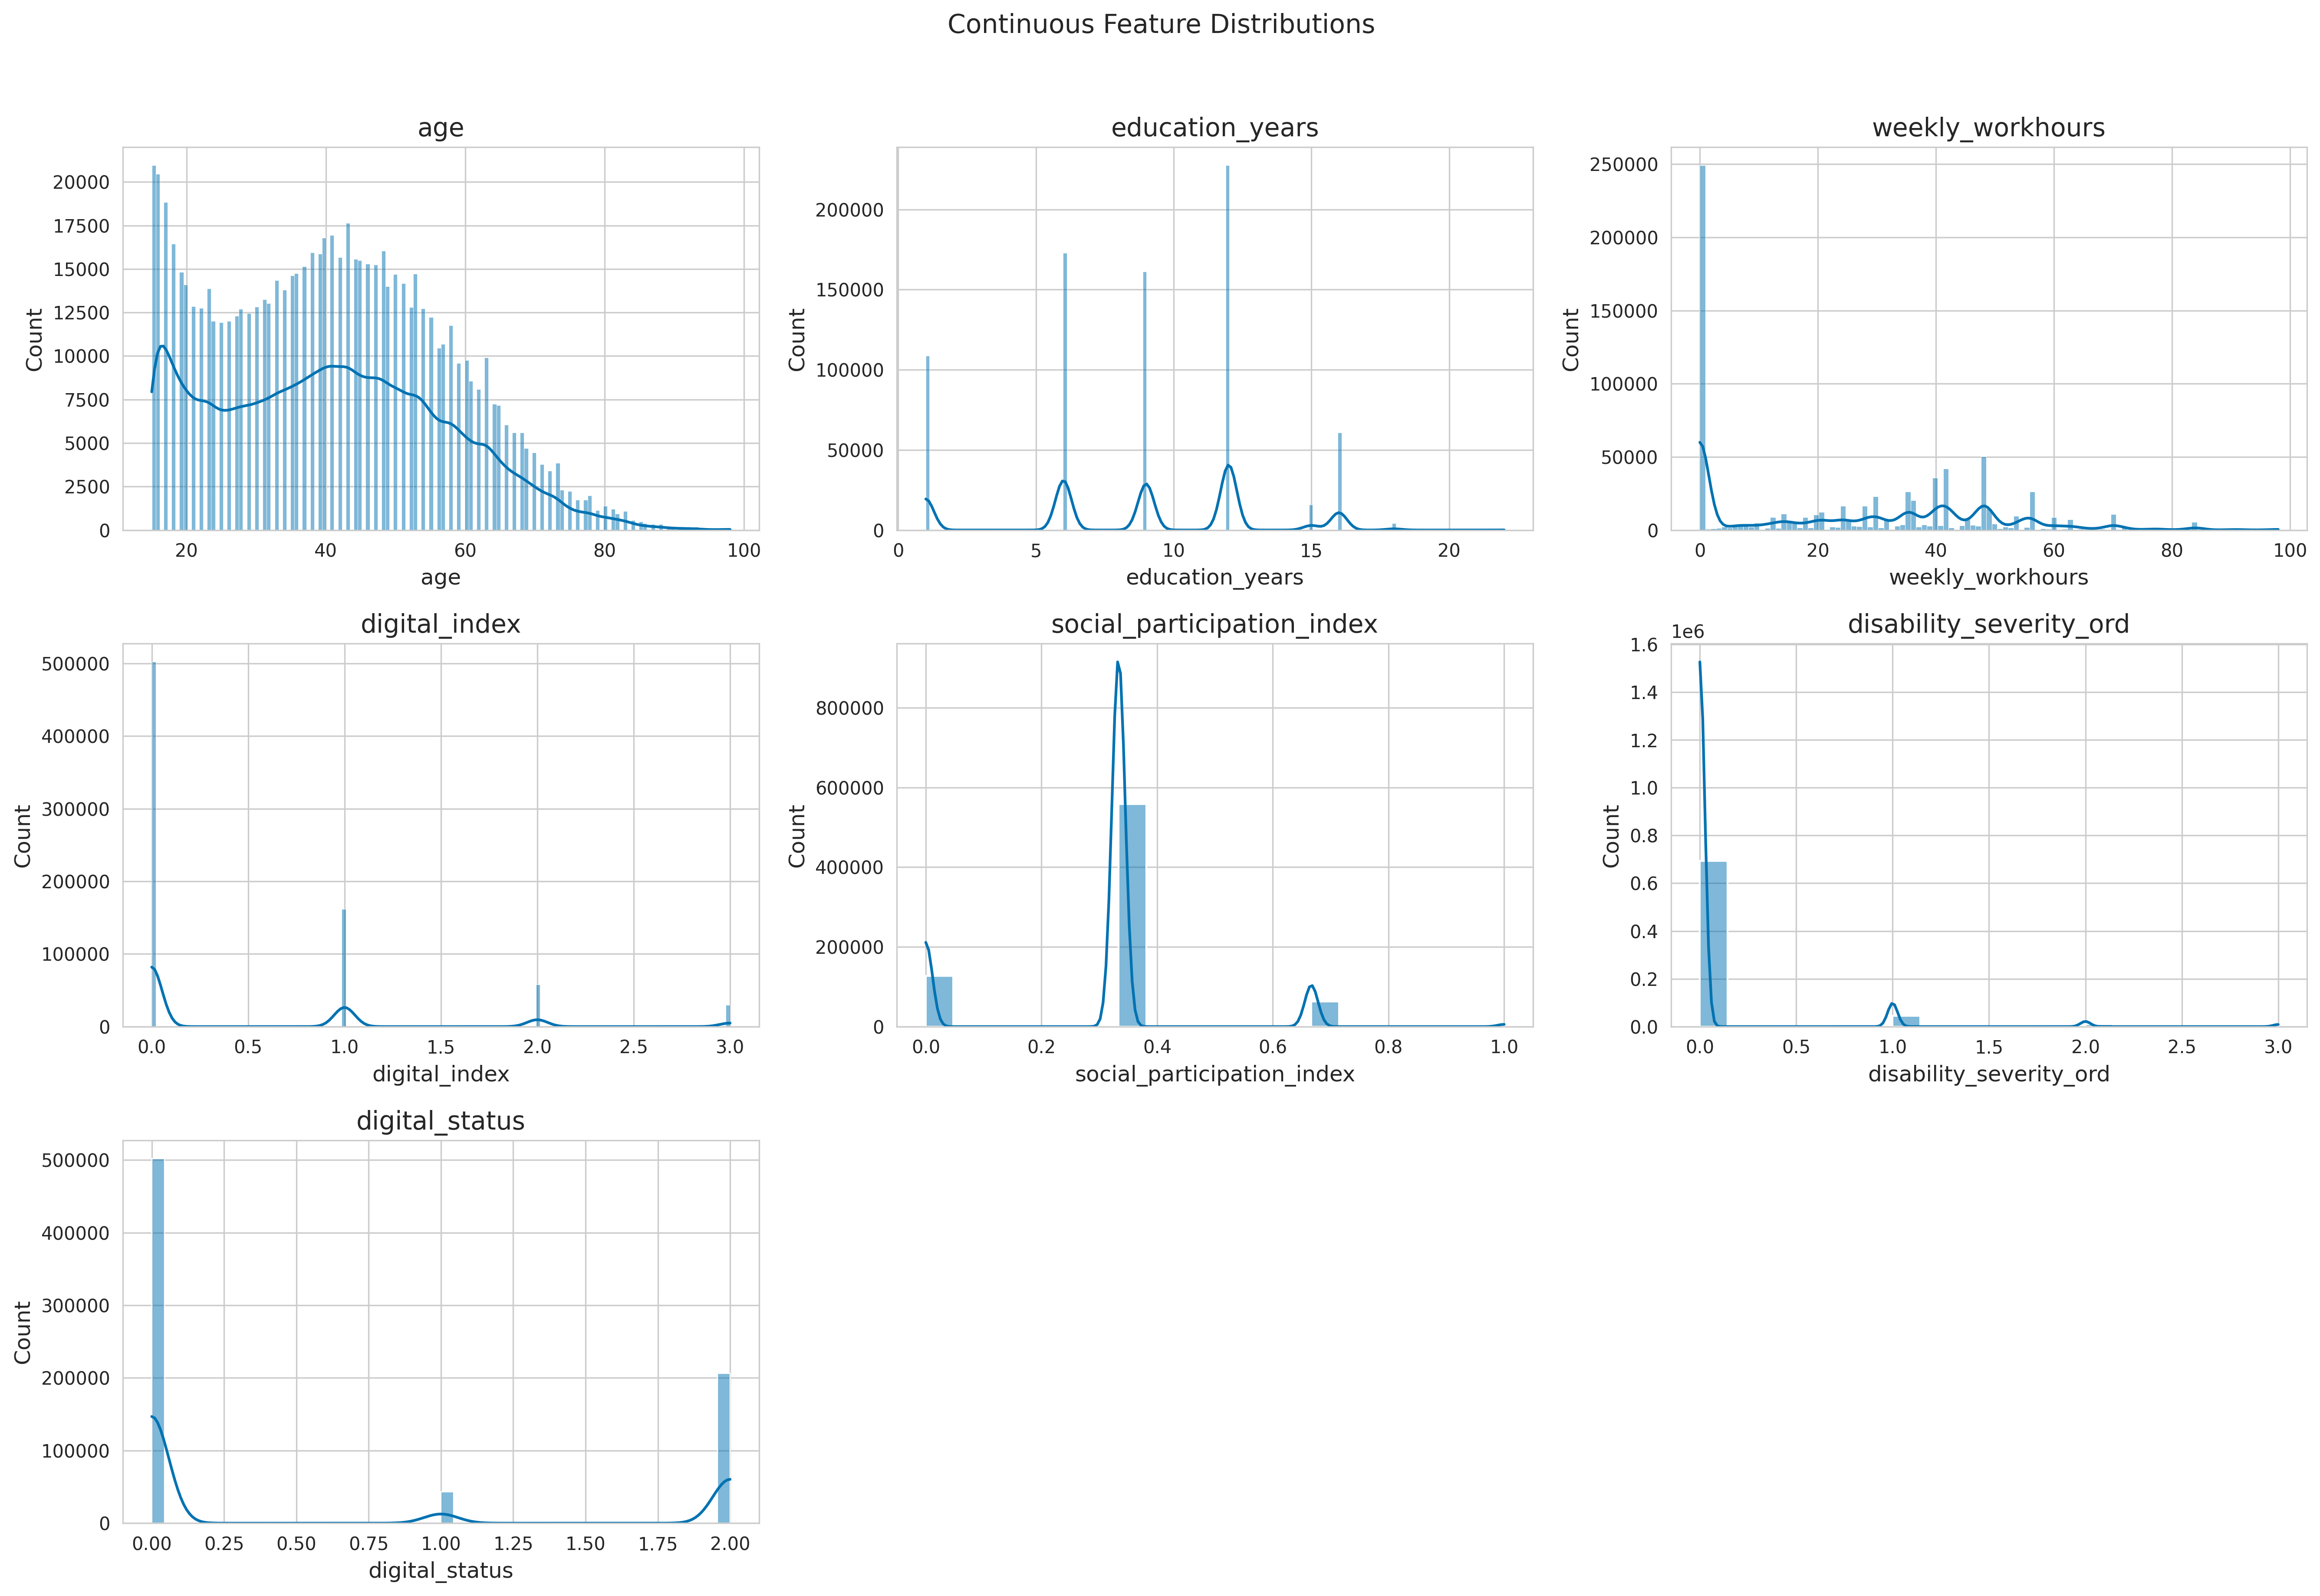

In [13]:
n_cols = 3
n_rows = -(-len(continuous_only) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_only):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=IEEE_PALETTE[0])
    ax.set_title(col)

for ax in axes[len(continuous_only):]:
    ax.axis('off')

plt.suptitle('Continuous Feature Distributions', y=1.02)
save_fig('continuous_feature_distributions')

## 8. Binary / flag feature prevalence
Shows what share of the dataset has each binary flag set to 1 (gender_male, disabled, agri_worker, region dummies, etc). More informative than a histogram for 0/1 columns.

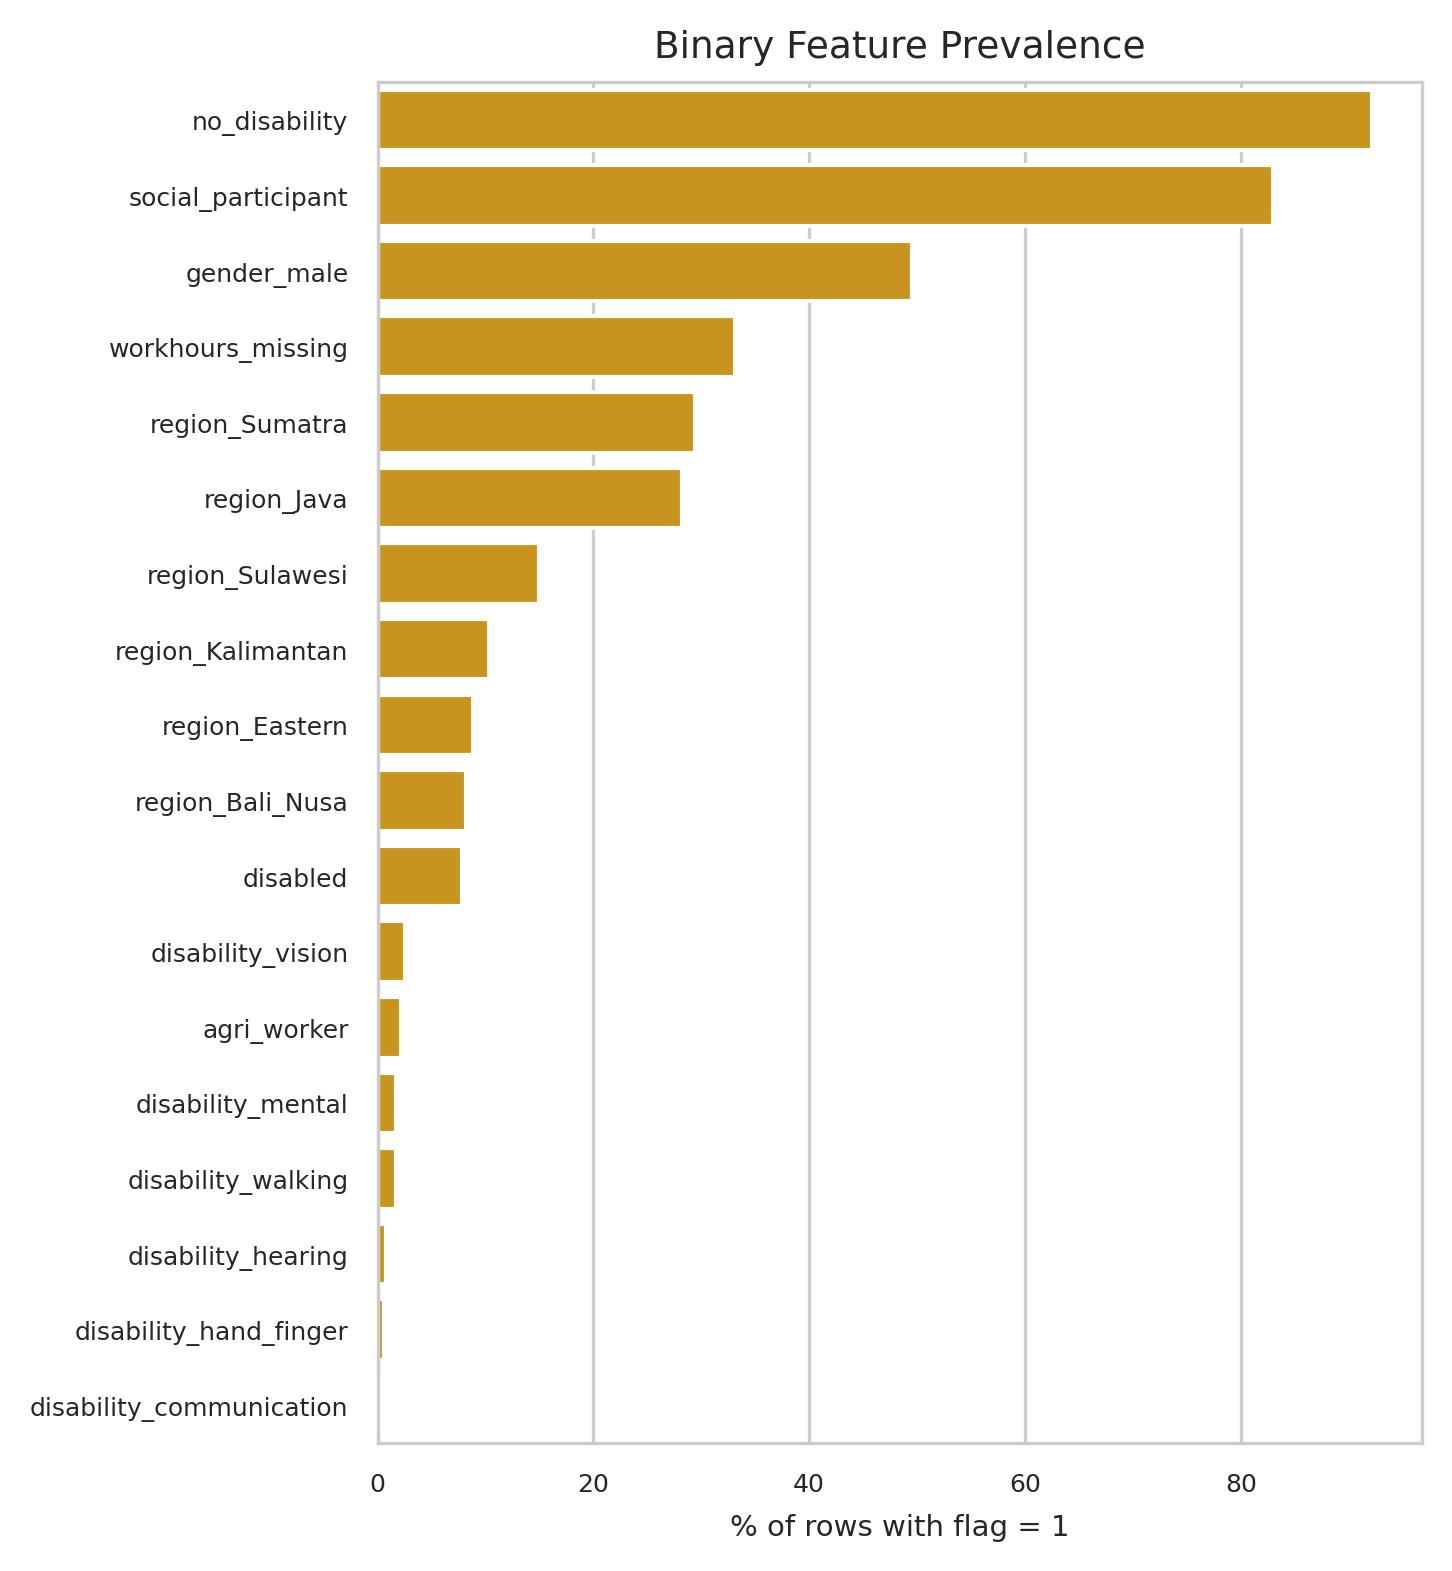

In [24]:
if binary_like:

    prevalence = df[binary_like].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(5, max(3.5, len(binary_like) * 0.3)))

    sns.barplot(
        x=prevalence.values,
        y=prevalence.index,
        color=IEEE_PALETTE[1]
    )

    plt.xlabel('% of rows with flag = 1', fontsize=7)
    plt.ylabel('', fontsize=7)
    plt.title('Binary Feature Prevalence', fontsize=9)

    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

    plt.tight_layout(pad=0.5)

    save_fig('binary_feature_prevalence')

else:

    print('No binary-like columns detected.')

## 9. digital_index by income_class
The core research relationship. This is the descriptive precursor to the MNLogit result already established for this project; it should visually show the same monotonic upward pattern.

/tmp/ipykernel_2625/2264496553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y='digital_index', order=order, palette=IEEE_PALETTE)
/tmp/ipykernel_2625/2264496553.py:3: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.boxplot(data=df, x=TARGET_COL, y='digital_index', order=order, palette=IEEE_PALETTE)


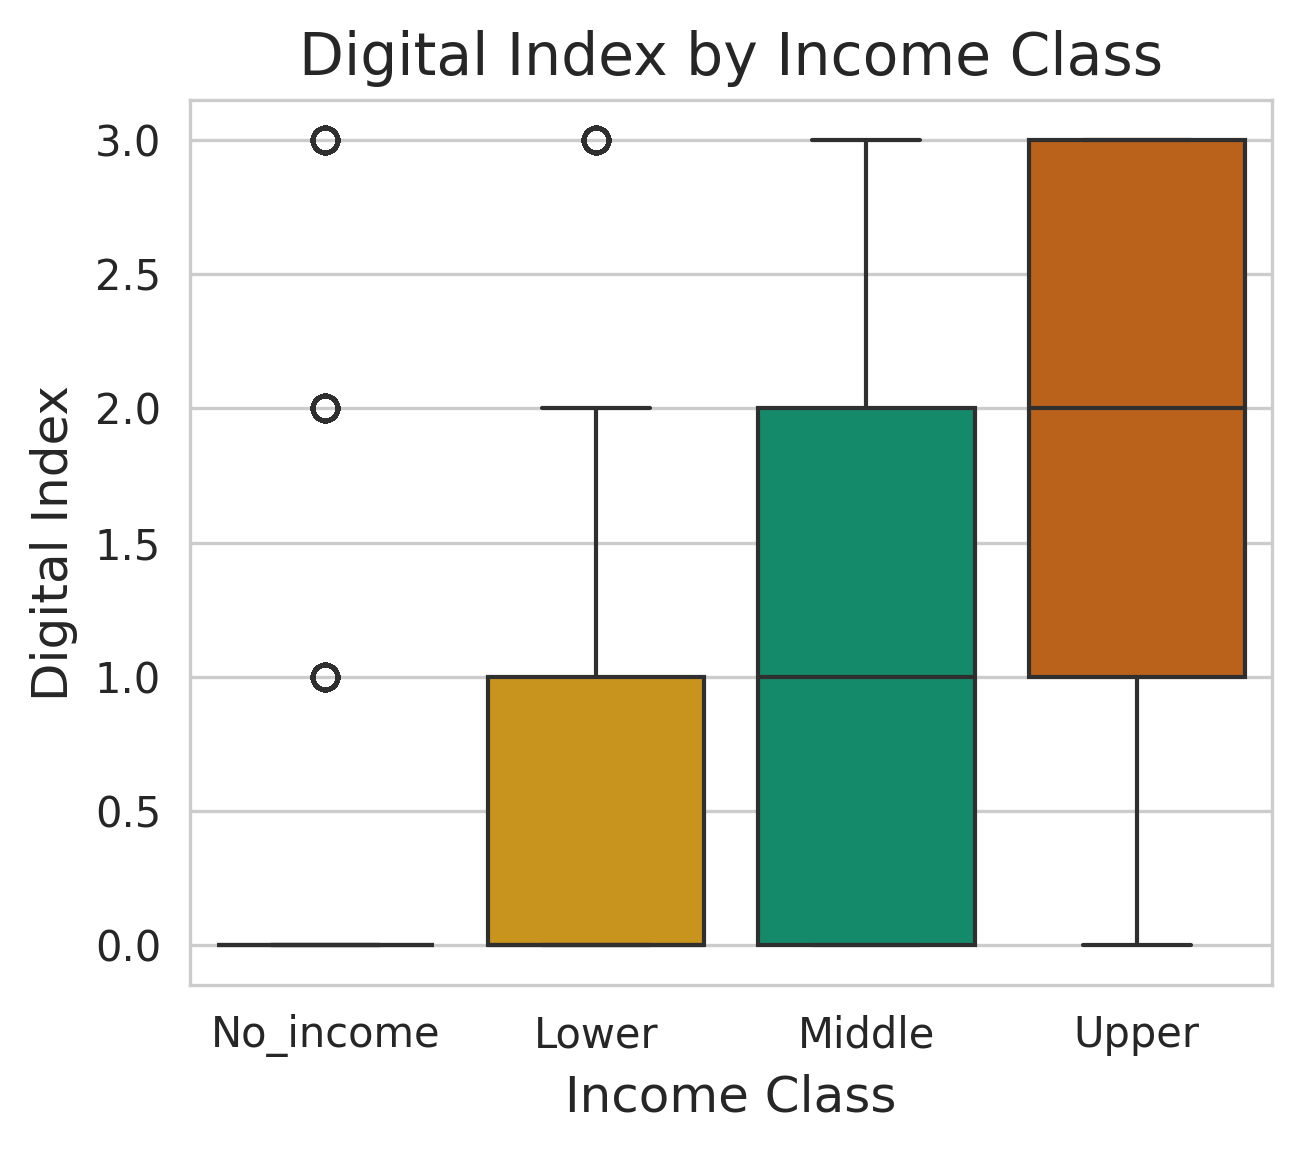

In [27]:
plt.figure(figsize=(4.5, 4))
order = class_counts.index.tolist()
sns.boxplot(data=df, x=TARGET_COL, y='digital_index', order=order, palette=IEEE_PALETTE)
plt.title('Digital Index by Income Class')
plt.xlabel('Income Class')
plt.ylabel('Digital Index')
save_fig('digital_index_by_income_class')

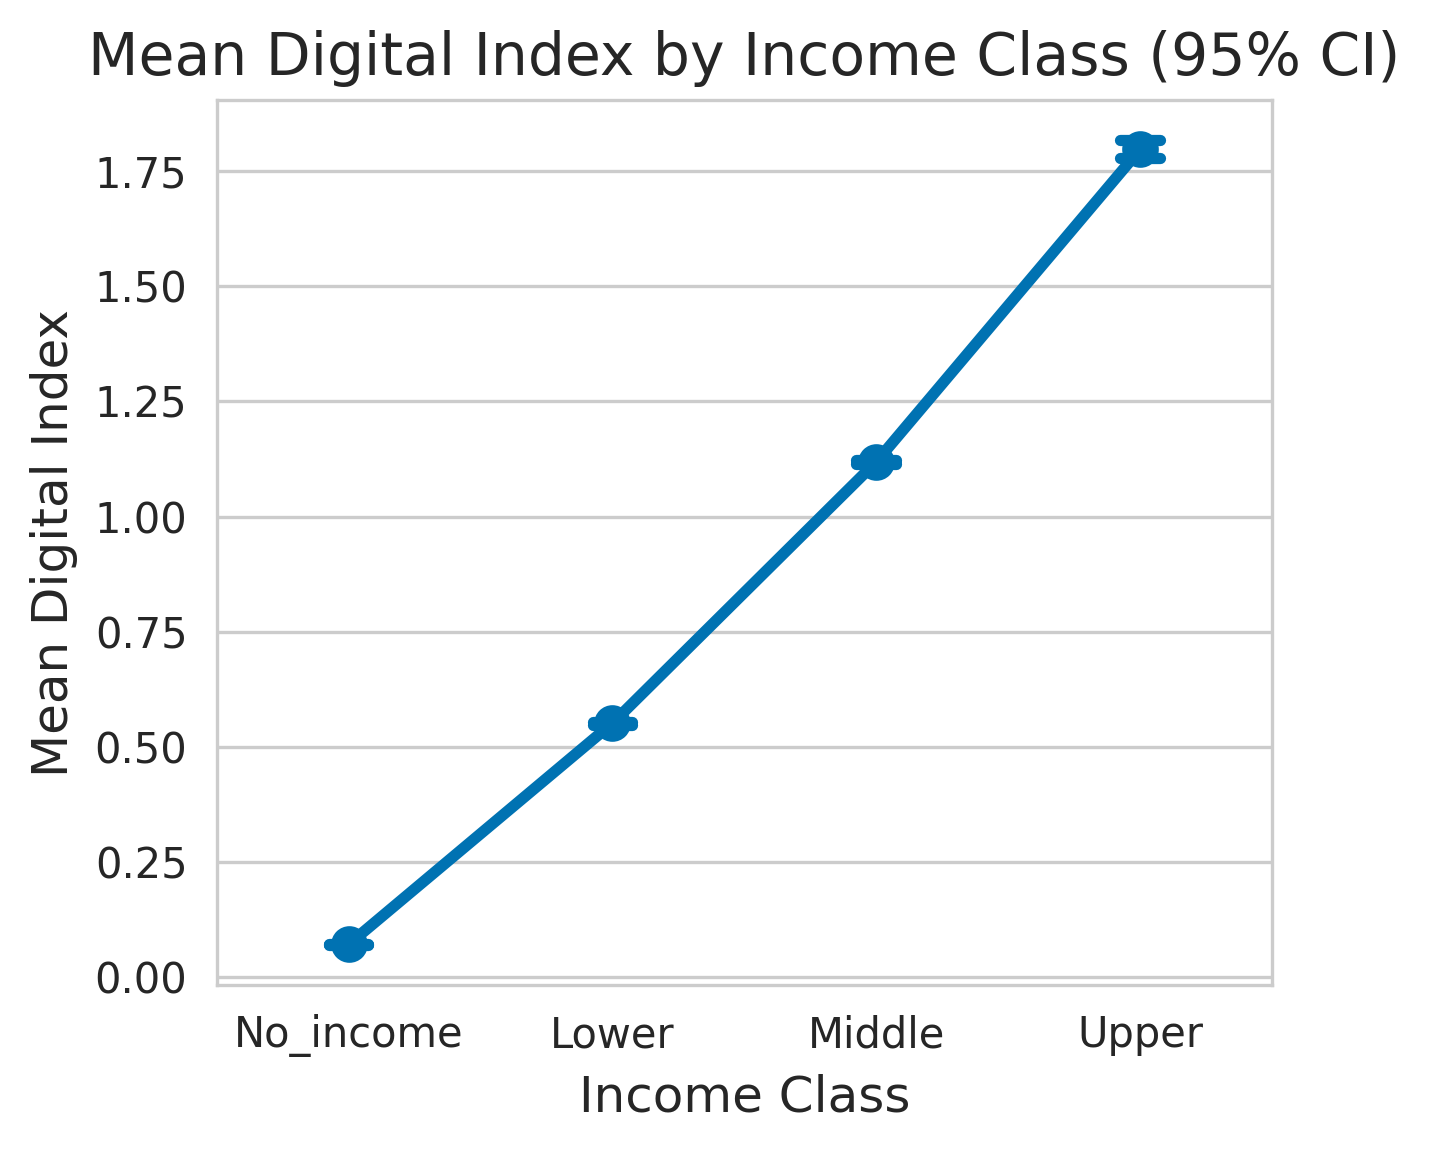

In [29]:
# Same relationship as a mean-with-error-bar chart, often clearer for a paper figure than a boxplot
plt.figure(figsize=(4.5, 4))
sns.pointplot(data=df, x=TARGET_COL, y='digital_index', order=order,
              color=IEEE_PALETTE[0], errorbar='ci', capsize=0.15)
plt.title('Mean Digital Index by Income Class (95% CI)')
plt.xlabel('Income Class')
plt.ylabel('Mean Digital Index')
save_fig('digital_index_by_income_class_pointplot')

## 10. Correlation heatmap (continuous features)
Flags potential redundancy before modeling, e.g. `digital_index` vs `digital_status`, which the project notes flagged as related-but-distinct and worth checking.

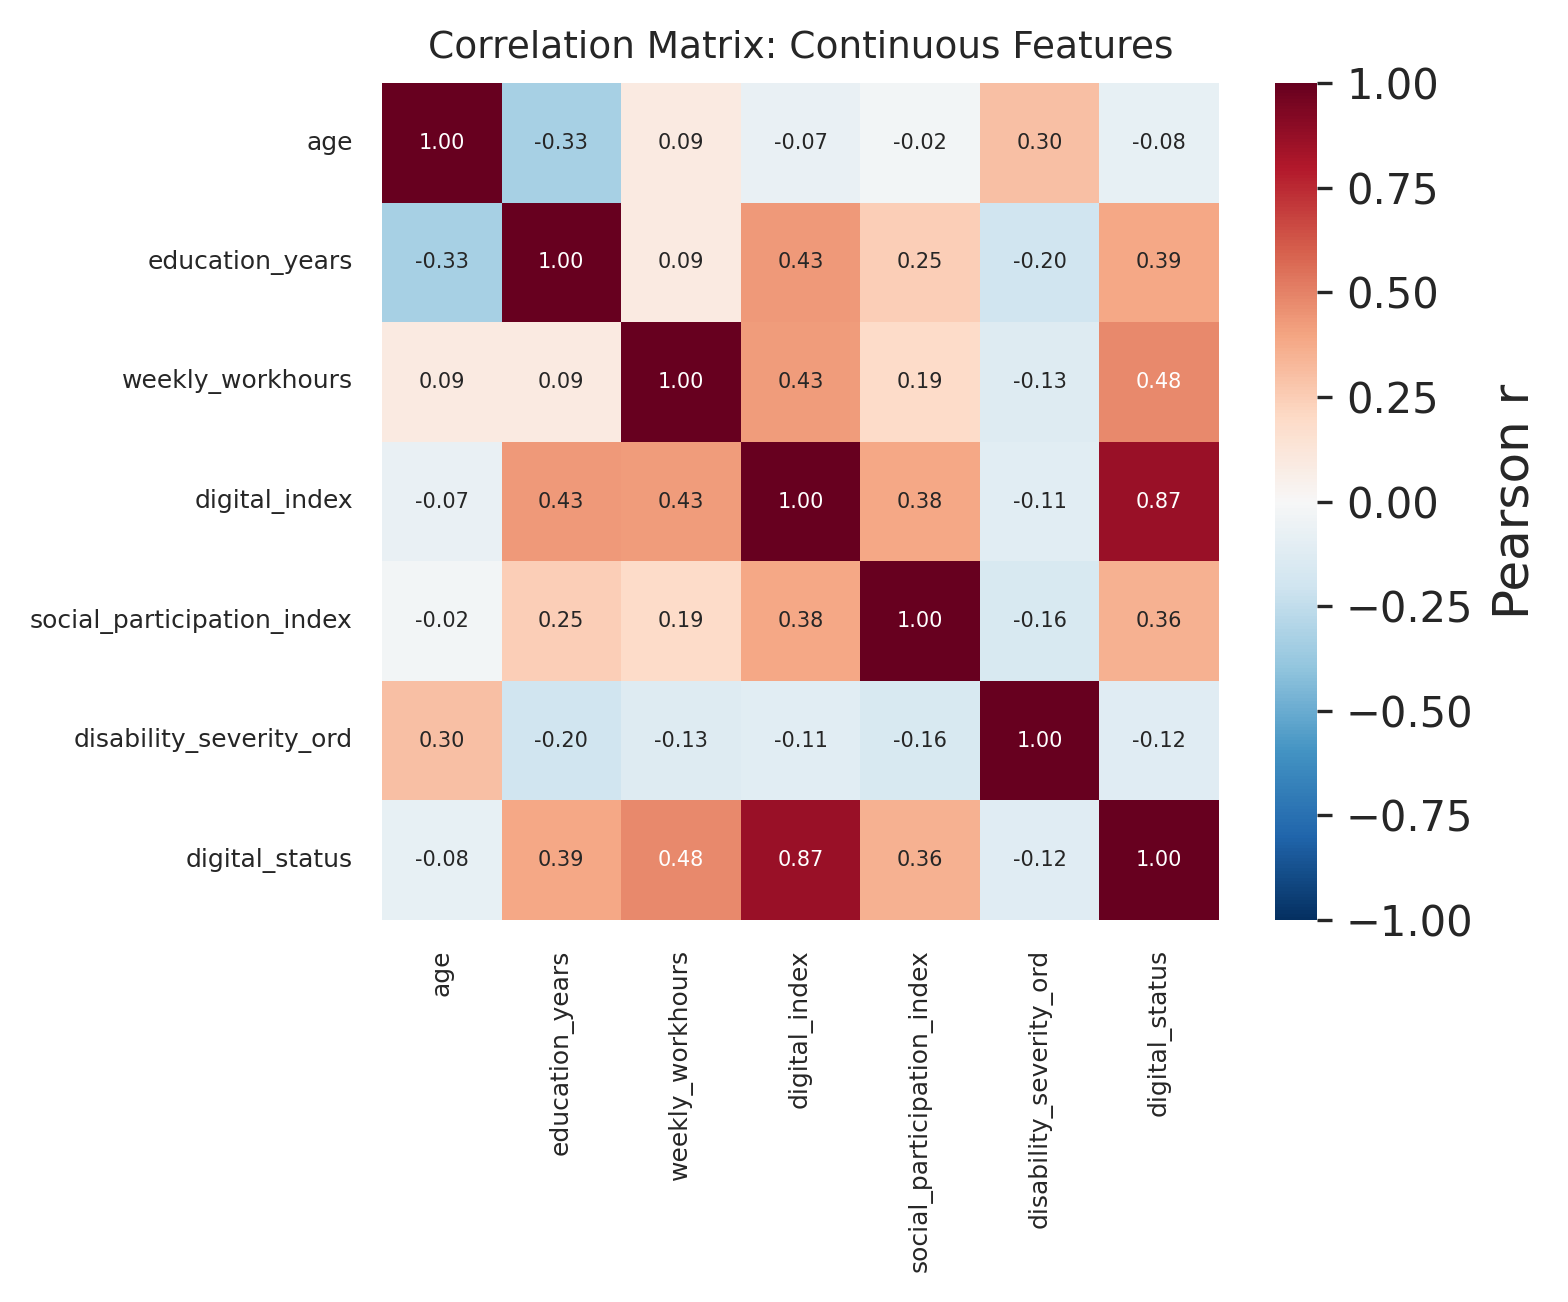

In [35]:
corr = df[continuous_only].corr()

plt.figure(figsize=(5.5, 4.5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={'fontsize': 5},
    cbar_kws={'label': 'Pearson r'}
)

plt.title('Correlation Matrix: Continuous Features', fontsize=9)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout(pad=0.5)

save_fig('correlation_heatmap')

## 11. Region distribution

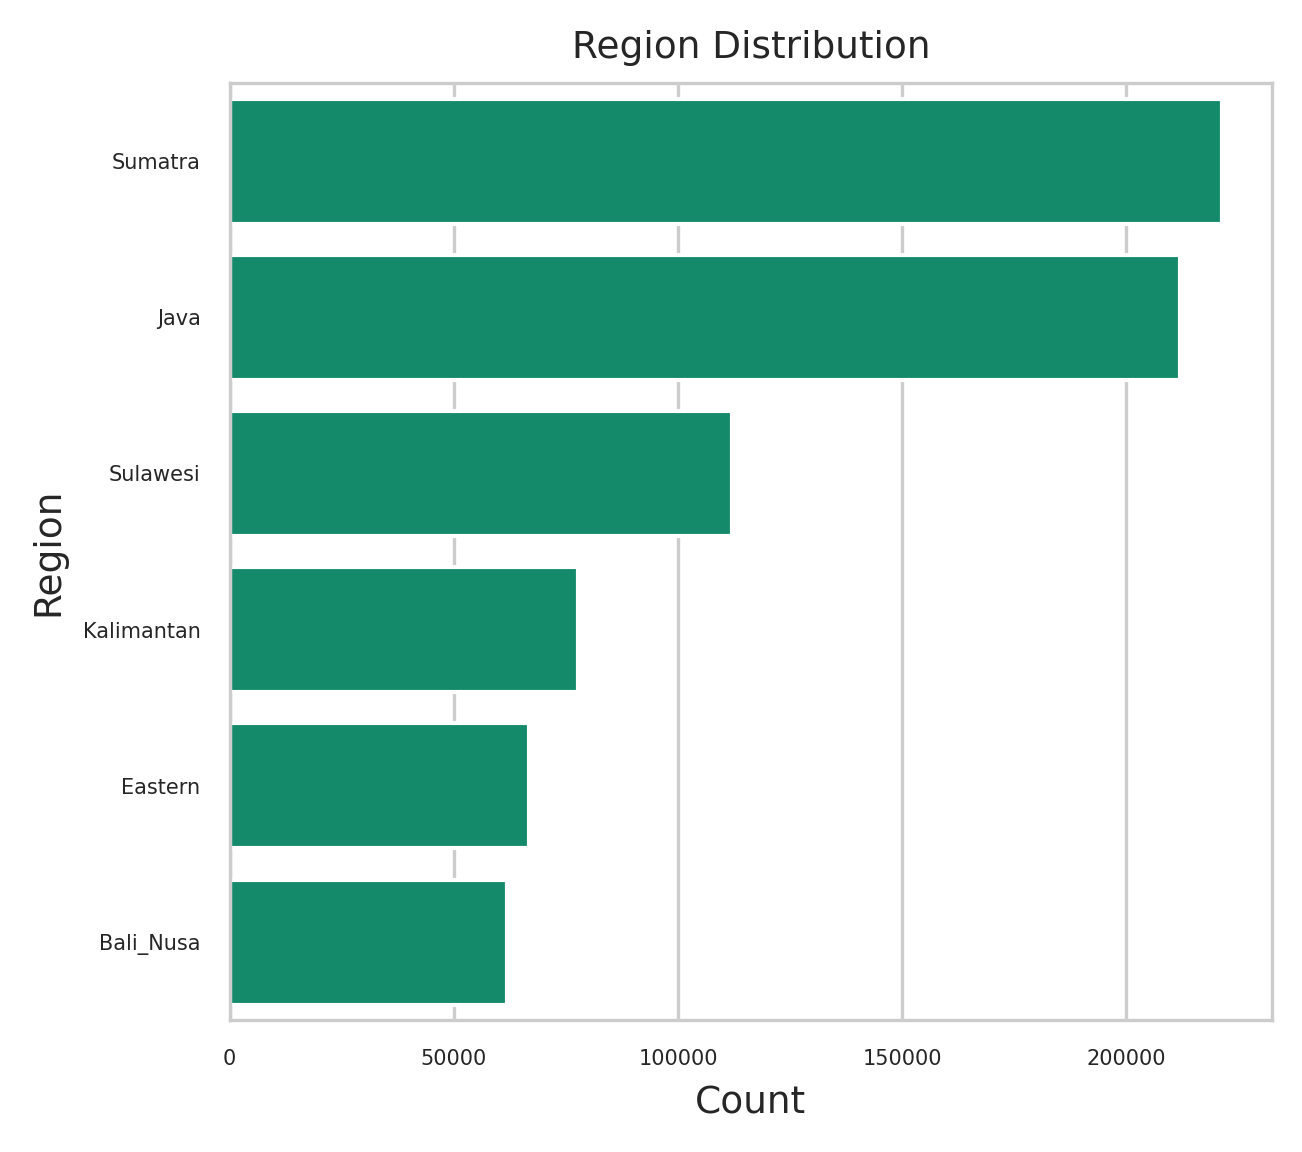

In [40]:
region_cols = [c for c in df.columns if c.startswith('region_')]
if region_cols:
    region_counts = df[region_cols].sum().sort_values(ascending=False)
    region_counts.index = region_counts.index.str.replace('region_', '')

    plt.figure(figsize=(4.5, 4))
    sns.barplot(x=region_counts.values, y=region_counts.index, color=IEEE_PALETTE[2])
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)
    plt.xlabel('Count',fontsize=9)
    plt.ylabel('Region',fontsize=9)
    plt.title('Region Distribution',fontsize=9)
    save_fig('region_distribution')
else:
    print('No region_* columns found, check actual column names from Section 2.')

## 12. Duplicate rows check

In [41]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.3f}% of dataset)')

Duplicate rows: 372,030 (49.497% of dataset)


## 13. Summary table for the profiling report
Saved to `docs/findings/`, this is the deliverable SPR-01 actually promises: a written distribution and upper-tail summary other tickets can reference without re-running this notebook.

In [42]:
summary_lines = []
summary_lines.append(f'# EDA Summary: SIGNAL Final Dataset\n')
summary_lines.append(f'Rows: {df.shape[0]:,}, Columns: {df.shape[1]}\n')
summary_lines.append(f'## Target Class Distribution ({TARGET_COL})\n')
for cls, count in class_counts.items():
    pct = class_pct[cls]
    summary_lines.append(f'- {cls}: {count:,} ({pct}%)\n')
summary_lines.append(f'\n## Upper-Tail Notes\n')
summary_lines.append(f'- Upper class share: {len(upper_df)/len(df)*100:.2f}%\n')
summary_lines.append(f'- Duplicate rows: {n_dupes:,}\n')
summary_lines.append(f'\n_Fill in qualitative observations after reviewing the figures above._\n')

with open('docs/findings/eda_summary.md', 'w') as f:
    f.writelines(summary_lines)

print('Saved docs/findings/eda_summary.md')
print(''.join(summary_lines))

Saved docs/findings/eda_summary.md
# EDA Summary: SIGNAL Final Dataset
Rows: 751,622, Columns: 26
## Target Class Distribution (income_class)
- No_income: 327,963 (43.63%)
- Lower: 239,425 (31.85%)
- Middle: 175,908 (23.4%)
- Upper: 8,326 (1.11%)

## Upper-Tail Notes
- Upper class share: 1.11%
- Duplicate rows: 372,030

_Fill in qualitative observations after reviewing the figures above._



## 14. Written findings
_Fill in after reviewing every figure above. This feeds SPR-08a (Introduction) and SPR-02 (imbalance strategy justification)._

- Most imbalanced class and its share:
- Any surprising correlations:
- Any data quality issues found (missingness, duplicates):
- Confirmed: does digital_index rise monotonically across income class visually, matching the MNLogit result: